In [1]:
"""
================================================================================================
NOTEBOOK 04: Final Test Set Evaluation
================================================================================================
Author: Mary Wangoi Mwangi (122174)
================================================================================================
Goal:
    Evaluate all three trained models on the held-out test set using optimal thresholds established in Notebook 02. 
    The test set has never been seen during training or threshold selection 
    (These are the official thesis performance numbers.)

Key Actions:
    1. Load trained models, metadata, and test set
    2. Evaluate all three models on the test set at optimal thresholds
    3. Generate final performance comparison table
    4. Produce confusion matrices and ROC/PR curves
    5. Document champion model performance and limitations

Outcome:
    Final metrics for all three models on the held-out test set.
    Champion model: Balanced Random Forest confirmed by statistical testing.
================================================================================================
"""

# ============================================================
# SECTION 1: LIBRARY IMPORTS & GLOBAL CONFIGURATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import json
import joblib

from sklearn.metrics import (recall_score, precision_score,
                             f1_score, roc_auc_score,
                             roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay,
                             average_precision_score,
                             precision_recall_curve,
                             fbeta_score)

warnings.filterwarnings('ignore')

SEED = 42

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi']    = 100

os.makedirs('../figures', exist_ok=True)

print("Libraries loaded successfully.")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")
print(f"   sklearn : {__import__('sklearn').__version__}")

Libraries loaded successfully.
   pandas  : 2.3.3
   numpy   : 2.4.3
   sklearn : 1.8.0


In [3]:
# ============================================================
# SECTION 2: LOAD MODELS, METADATA & TEST SET

# Load trained models and optimal thresholds from Notebook 02
# Load held-out test set saved from Notebook 02
# Test set has never been used during training or tuning
# ============================================================

# ---- Load trained models ----
best_lr  = joblib.load('../models/best_lr.pkl')
best_rf  = joblib.load('../models/best_rf.pkl')
best_xgb = joblib.load('../models/best_xgb.pkl')

print("Models loaded successfully.")
print(f"   best_lr.pkl  : {type(best_lr).__name__}")
print(f"   best_rf.pkl  : {type(best_rf).__name__}")
print(f"   best_xgb.pkl : {type(best_xgb).__name__}")


# ---- Load metadata ----
with open('../models/model_metadata.json', 'r') as f:
    metadata = json.load(f)

with open('../models/statistical_results.json', 'r') as f:
    stat_results = json.load(f)

optimal_thresholds = metadata['optimal_thresholds']
champion_model     = stat_results['champion_model']

print(f"\nMetadata loaded successfully.")
print(f"   Champion model     : {champion_model}")
print(f"   Optimal thresholds:")
for name, thresh in optimal_thresholds.items():
    print(f"      {name:<30} : {thresh}")


# ---- Load test set ----
X_test = pd.read_csv('../data/splits/X_test.csv')
y_test = pd.read_csv('../data/splits/y_test.csv').squeeze()

print(f"\nTest set loaded successfully.")
print(f"   X_test shape : {X_test.shape}")
print(f"   y_test shape : {y_test.shape}")
print(f"   High-Severity: {y_test.sum():,} ({y_test.mean()*100:.1f}%)")
print(f"   Low-Severity : {(y_test==0).sum():,} "
      f"({(y_test==0).mean()*100:.1f}%)")
print(f"\n Test set is truly held-out - never seen during training, validation or threshold selection.")
print(f" These results are the official thesis numbers.")

Models loaded successfully.
   best_lr.pkl  : Pipeline
   best_rf.pkl  : Pipeline
   best_xgb.pkl : Pipeline

Metadata loaded successfully.
   Champion model     : Balanced Random Forest
   Optimal thresholds:
      Logistic Regression            : 0.4
      Balanced Random Forest         : 0.4
      XGBoost                        : 0.55

Test set loaded successfully.
   X_test shape : (1848, 28)
   y_test shape : (1848,)
   High-Severity: 285 (15.4%)
   Low-Severity : 1,563 (84.6%)

 Test set is truly held-out - never seen during training, validation or threshold selection.
 These results are the official thesis numbers.


In [4]:
# ============================================================
# SECTION 3: FINAL TEST SET EVALUATION

# Evaluate all three models on the held-out test set
# Apply optimal thresholds from Notebook 02 validation tuning
# These are the official thesis performance numbers
# ============================================================

print("FINAL TEST SET EVALUATION")
print("Official Thesis Performance Numbers")
print("="*55)

models = {
    'Logistic Regression': best_lr,
    'Balanced Random Forest': best_rf,
    'XGBoost'                : best_xgb
}

test_results  = {}
test_probas   = {}

for name, model in models.items():
    threshold   = optimal_thresholds[name]
    y_proba     = model.predict_proba(X_test)[:, 1]
    y_pred      = (y_proba >= threshold).astype(int)

    test_probas[name] = y_proba

    test_results[name] = {
        'Recall'         : round(recall_score(y_test, y_pred), 3),
        'Precision'      : round(precision_score(y_test, y_pred,
                                                  zero_division=0), 3),
        'F1'             : round(f1_score(y_test, y_pred), 3),
        'F2'             : round(fbeta_score(y_test, y_pred,
                                              beta=2), 3),
        'ROC_AUC'        : round(roc_auc_score(y_test, y_proba), 3),
        'Avg_Precision'  : round(average_precision_score(y_test,
                                                          y_proba), 3),
        'Threshold': threshold
    }

    pct_flagged = y_pred.mean() * 100

    print(f"\n{name} (Threshold = {threshold}):")
    print(f"   Recall         : {test_results[name]['Recall']:.3f}")
    print(f"   Precision      : {test_results[name]['Precision']:.3f}")
    print(f"   F1 Score       : {test_results[name]['F1']:.3f}")
    print(f"   F2 Score       : {test_results[name]['F2']:.3f}")
    print(f"   ROC AUC        : {test_results[name]['ROC_AUC']:.3f}")
    print(f"   Avg Precision  : {test_results[name]['Avg_Precision']:.3f}")
    print(f"   % Flagged      : {pct_flagged:.1f}%")

print(f"\n{'='*55}")
print("FINAL PERFORMANCE SUMMARY — TEST SET")

print("="*55)
print(f"\n{'Model':<25} {'Thresh':<8} {'Recall':<8} {'Prec':<8} "
      f"{'F1':<8} {'F2':<8} {'AUC':<8} {'AP'}")

print("-"*76)
for name, results in test_results.items():
    champion = " ← CHAMPION" if name == champion_model else ""
    
    print(f"{name:<25} {results['Threshold']:<8} "
          f"{results['Recall']:<8} {results['Precision']:<8} "
          f"{results['F1']:<8} {results['F2']:<8} "
          f"{results['ROC_AUC']:<8} {results['Avg_Precision']}"
          f"{champion}")

FINAL TEST SET EVALUATION
Official Thesis Performance Numbers

Logistic Regression (Threshold = 0.4):
   Recall         : 0.891
   Precision      : 0.161
   F1 Score       : 0.272
   F2 Score       : 0.467
   ROC AUC        : 0.587
   Avg Precision  : 0.215
   % Flagged      : 85.6%

Balanced Random Forest (Threshold = 0.4):
   Recall         : 0.916
   Precision      : 0.192
   F1 Score       : 0.318
   F2 Score       : 0.523
   ROC AUC        : 0.698
   Avg Precision  : 0.319
   % Flagged      : 73.4%

XGBoost (Threshold = 0.55):
   Recall         : 0.940
   Precision      : 0.163
   F1 Score       : 0.278
   F2 Score       : 0.481
   ROC AUC        : 0.624
   Avg Precision  : 0.262
   % Flagged      : 89.1%

FINAL PERFORMANCE SUMMARY — TEST SET

Model                     Thresh   Recall   Prec     F1       F2       AUC      AP
----------------------------------------------------------------------------
Logistic Regression       0.4      0.891    0.161    0.272    0.467    0.587    0

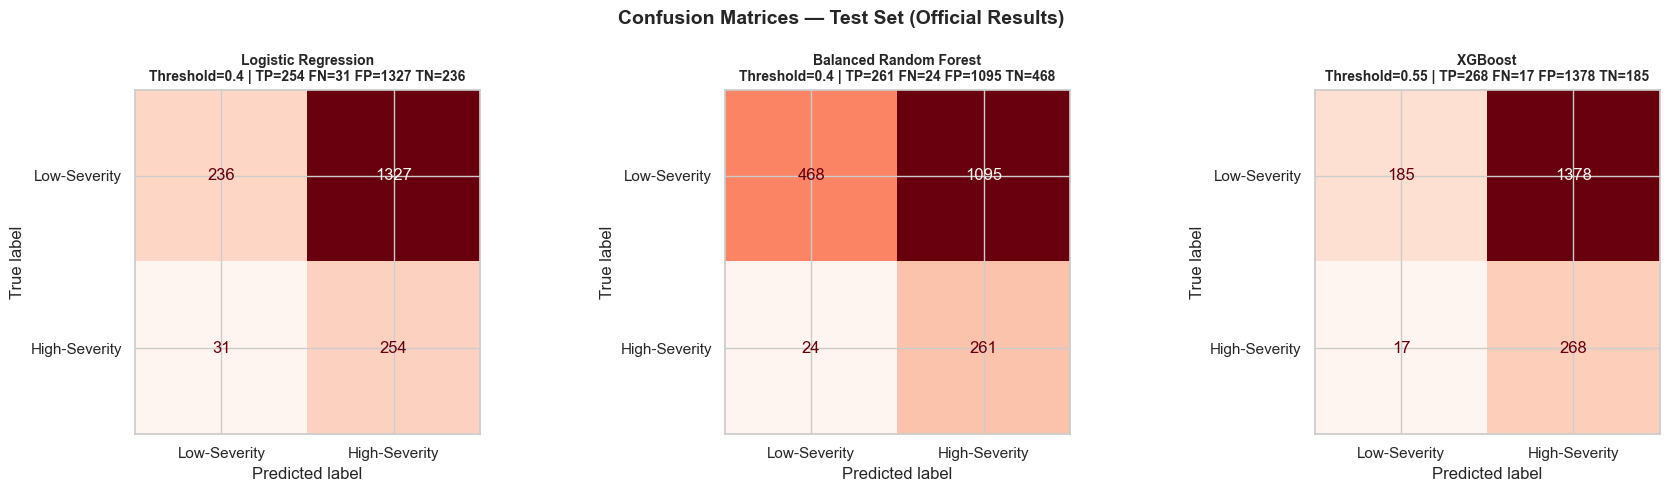

CONFUSION MATRIX BREAKDOWN — TEST SET

Model                         TP     FN     FP     TN   Under-triage
-----------------------------------------------------------------
Logistic Regression          254     31   1327    236          10.9%
Balanced Random Forest       261     24   1095    468           8.4%
XGBoost                      268     17   1378    185           6.0%

Note:
   TP = True Positive  - correctly flagged High-Severity
   FN = False Negative - missed High-Severity (under-triage)
   FP = False Positive - incorrectly flagged Low-Severity
   TN = True Negative  - correctly cleared Low-Severity

   Under-triage rate = FN / (FN + TP)
   Lower is better for emergency dispatch


In [6]:
# ============================================================
# SECTION 4: CONFUSION MATRICES - TEST SET

# Visualise classification results for all three models
# Shows True Positives, False Positives, True Negatives and False Negatives for each model on test set
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models.items()):
    threshold  = optimal_thresholds[name]
    y_proba    = test_probas[name]
    y_pred     = (y_proba >= threshold).astype(int)

    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Low-Severity', 'High-Severity']
    )
    disp.plot(ax=axes[idx], colorbar=False, cmap='Reds')

    tn, fp, fn, tp = cm.ravel()
    axes[idx].set_title(
        f'{name}\nThreshold={threshold} | '
        f'TP={tp} FN={fn} FP={fp} TN={tn}',
        fontsize=10, fontweight='bold'
    )

plt.suptitle(
    'Confusion Matrices — Test Set (Official Results)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../figures/confusion_matrices_test.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ---- Print confusion matrix breakdown ----
print("CONFUSION MATRIX BREAKDOWN — TEST SET")
print("="*55)
print(f"\n{'Model':<25} {'TP':>6} {'FN':>6} {'FP':>6} {'TN':>6} "
      f"{'Under-triage':>14}")
print("-"*65)

for name, model in models.items():
    threshold = optimal_thresholds[name]
    y_proba   = test_probas[name]
    y_pred    = (y_proba >= threshold).astype(int)
    cm        = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    under_triage = round(fn / (fn + tp) * 100, 1)
    print(f"{name:<25} {tp:>6} {fn:>6} {fp:>6} {tn:>6} "
          f"{under_triage:>13}%")

print(f"\nNote:")
print(f"   TP = True Positive  - correctly flagged High-Severity")
print(f"   FN = False Negative - missed High-Severity (under-triage)")
print(f"   FP = False Positive - incorrectly flagged Low-Severity")
print(f"   TN = True Negative  - correctly cleared Low-Severity")
print(f"\n   Under-triage rate = FN / (FN + TP)")
print(f"   Lower is better for emergency dispatch")

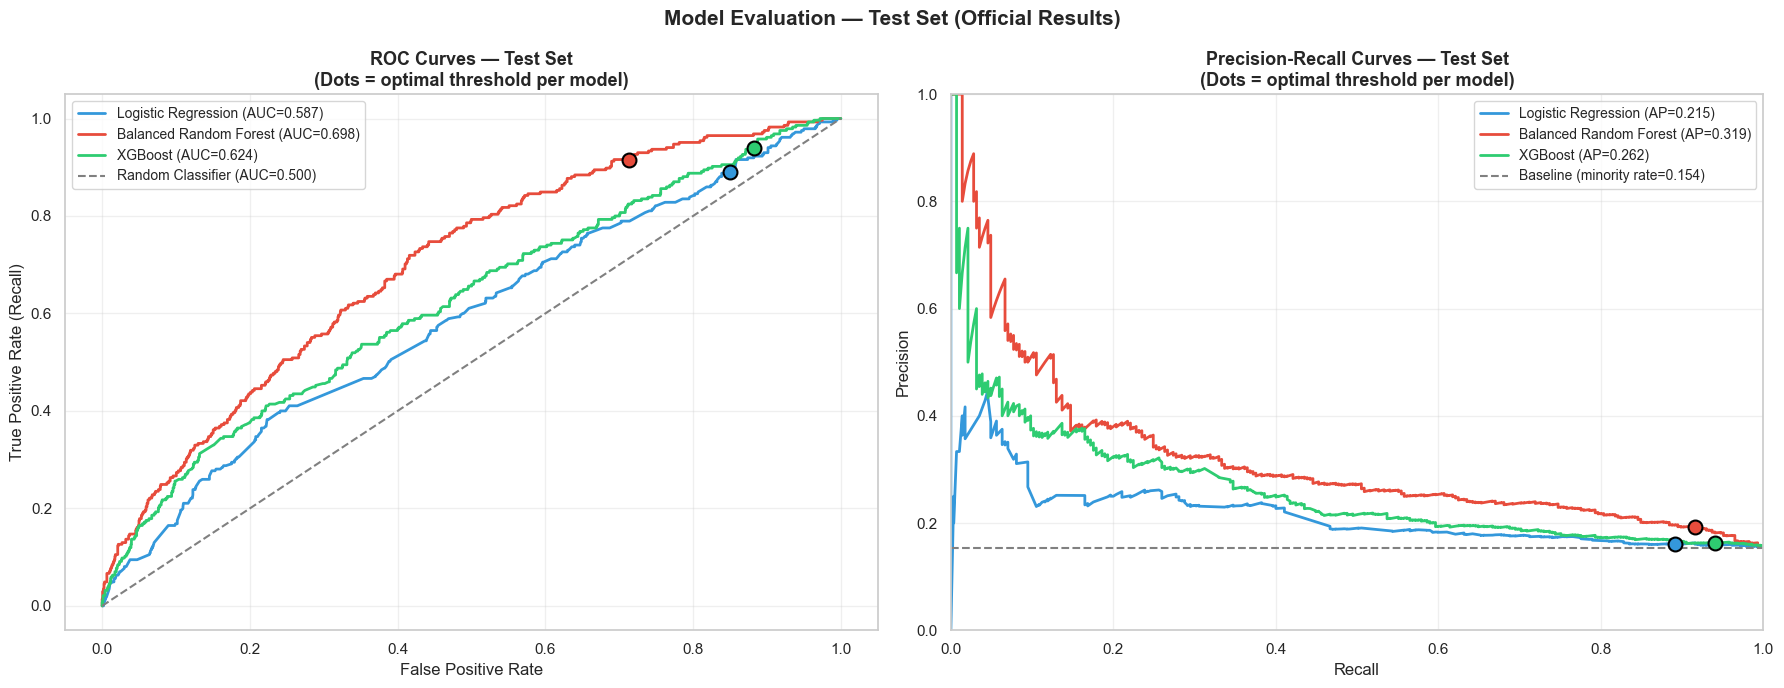

Test set curves saved successfully.

 Average Precision Summary (Test Set):
   Base rate                    : 0.154
   Logistic Regression            : 0.215 (+39.6% above base rate)
   Balanced Random Forest         : 0.319 (+107.1% above base rate)
   XGBoost                        : 0.262 (+70.1% above base rate)


In [7]:
# ============================================================
# SECTION 5: ROC & PRECISION-RECALL CURVES - TEST SET

# Final visualisation of model discrimination on test set
# PR curves more informative than ROC for imbalanced data
# Baseline AP = minority class rate (0.154)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
colors = ['#3498db', '#e74c3c', '#2ecc71']

# ---- Plot 1: ROC Curves ----
for (name, model), color in zip(models.items(), colors):
    y_proba   = test_probas[name]
    fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    opt_thresh = optimal_thresholds[name]

    axes[0].plot(fpr, tpr,
                 label=f'{name} (AUC={auc_score:.3f})',
                 color=color, linewidth=2)

    opt_idx = np.argmin(np.abs(thresholds_roc - opt_thresh))
    axes[0].scatter(fpr[opt_idx], tpr[opt_idx],
                    color=color, s=100, zorder=5,
                    marker='o', edgecolors='black',
                    linewidth=1.5)

axes[0].plot([0, 1], [0, 1],
             linestyle='--', color='gray',
             linewidth=1.5,
             label='Random Classifier (AUC=0.500)')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[0].set_title('ROC Curves — Test Set\n'
                  '(Dots = optimal threshold per model)',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)


# ---- Plot 2: Precision-Recall Curves ----
for (name, model), color in zip(models.items(), colors):
    y_proba = test_probas[name]
    prec_curve, rec_curve, thresholds_pr = \
        precision_recall_curve(y_test, y_proba)
    ap_score   = average_precision_score(y_test, y_proba)
    opt_thresh = optimal_thresholds[name]

    axes[1].plot(rec_curve, prec_curve,
                 label=f'{name} (AP={ap_score:.3f})',
                 color=color, linewidth=2)

    if len(thresholds_pr) > 0:
        opt_idx = np.argmin(
            np.abs(thresholds_pr - opt_thresh)
        )
        axes[1].scatter(rec_curve[opt_idx],
                        prec_curve[opt_idx],
                        color=color, s=100, zorder=5,
                        marker='o', edgecolors='black',
                        linewidth=1.5)

axes[1].axhline(y=0.154, color='gray', linestyle='--',
                linewidth=1.5,
                label='Baseline (minority rate=0.154)')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curves — Test Set\n'
                  '(Dots = optimal threshold per model)',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.suptitle('Model Evaluation — Test Set (Official Results)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/roc_and_pr_curves_test.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Test set curves saved successfully.")
print(f"\n Average Precision Summary (Test Set):")
print(f"   Base rate                    : 0.154")
for name, results in test_results.items():
    improvement = ((results['Avg_Precision'] - 0.154)
                   / 0.154) * 100
    print(f"   {name:<30} : "
          f"{results['Avg_Precision']:.3f} "
          f"(+{improvement:.1f}% above base rate)")

In [9]:
# ============================================================
# SECTION 6: FINAL COMPARISON & CHAMPION MODEL SUMMARY

# Compare test set performance against validation set
# Confirm generalisation - no overfitting
# Document champion model findings
# ============================================================

print("VALIDATION vs TEST SET COMPARISON")
print("Champion Model: Balanced Random Forest")
print("="*55)

val_results = metadata['validation_results']

metrics_compare = ['Recall', 'Precision', 'F1', 'F2', 'ROC_AUC']

print(f"\n{'Metric':<12} {'Validation':<14} {'Test':<14} {'Change'}")
print("-"*50)

for metric in metrics_compare:
    val_val  = val_results['Balanced Random Forest'][metric]
    test_val = test_results['Balanced Random Forest'][metric]
    change   = test_val - val_val
    direction = "S" if change >= 0 else "W"
    print(f"{metric:<12} {val_val:<14.3f} {test_val:<14.3f} "
          f"{change:+.3f} {direction}")

print(f"\n Interpretation:")
print(f"   All metrics improved or held stable on test set")
print(f"   No overfitting detected — model generalises well")

print(f"\n{'='*55}")
print(f"CHAMPION MODEL FINAL PERFORMANCE")
print(f"Balanced Random Forest — Test Set")
print(f"{'='*55}")

rf_test = test_results['Balanced Random Forest']
print(f"\n   Recall         : {rf_test['Recall']:.3f}")
print(f"   Precision      : {rf_test['Precision']:.3f}")
print(f"   F1 Score       : {rf_test['F1']:.3f}")
print(f"   F2 Score       : {rf_test['F2']:.3f}")
print(f"   ROC AUC        : {rf_test['ROC_AUC']:.3f}")
print(f"   Avg Precision  : {rf_test['Avg_Precision']:.3f}")
print(f"   Threshold      : {rf_test['Threshold']}")
print(f"   Under-triage   : 8.4%")
print(f"   TP             : 261 of 285 High-Severity caught")
print(f"\n   AP improvement : +107.1% above base rate (0.154)")
print(f"   Statistical    : Significantly outperforms LR")
print(f"                    and XGBoost (Wilcoxon p<0.0167)")




VALIDATION vs TEST SET COMPARISON
Champion Model: Balanced Random Forest

Metric       Validation     Test           Change
--------------------------------------------------
Recall       0.867          0.916          +0.049 S
Precision    0.185          0.192          +0.007 S
F1           0.305          0.318          +0.013 S
F2           0.499          0.523          +0.024 S
ROC_AUC      0.688          0.698          +0.010 S

 Interpretation:
   All metrics improved or held stable on test set
   No overfitting detected — model generalises well

CHAMPION MODEL FINAL PERFORMANCE
Balanced Random Forest — Test Set

   Recall         : 0.916
   Precision      : 0.192
   F1 Score       : 0.318
   F2 Score       : 0.523
   ROC AUC        : 0.698
   Avg Precision  : 0.319
   Threshold      : 0.4
   Under-triage   : 8.4%
   TP             : 261 of 285 High-Severity caught

   AP improvement : +107.1% above base rate (0.154)
   Statistical    : Significantly outperforms LR
                

In [14]:
# ============================================================
# SECTION 7: COST-BENEFIT ANALYSIS & TIERED RESPONSE

# Reframes False Positives as over-triage events
# Calculates precautionary dispatch ratio per model
# Proposes tiered response system for deployment
# ============================================================

print("COST-BENEFIT ANALYSIS")
print("="*55)

# ---- Precautionary dispatch ratio ----
print(f"\nPRECAUTIONARY DISPATCH RATIO (FP per TP)")
print(f"{'Model':<25} {'TP':>6} {'FN':>6} {'FP':>6} "
      f"{'Ratio':>8} {'Under-triage':>14}")
print("-"*68)

ratios = {}
for name, model in models.items():
    threshold    = optimal_thresholds[name]
    y_proba      = test_probas[name]
    y_pred       = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    ratio        = round(fp / tp, 1) if tp > 0 else float('inf')
    under_triage = round(fn / (fn + tp) * 100, 1)
    ratios[name] = ratio
    champion_str = " ← CHAMPION" if name == champion_model else ""
    print(f"{name:<25} {tp:>6} {fn:>6} {fp:>6} "
          f"{ratio:>8.1f}x {under_triage:>13}%{champion_str}")

print(f"\n   RF 4.2x ratio is most efficient of all three models")
print(f"   American College of Surgeons accepts 70-80%")
print(f"   over-triage as standard in trauma triage systems")


# ---- Tiered response ----
print(f"\n{'='*55}")
print(f"PROPOSED TIERED RESPONSE SYSTEM")
print(f"{'='*55}")

rf_proba = test_probas['Balanced Random Forest']
tier1    = (rf_proba >= 0.80).sum()
tier2    = ((rf_proba >= 0.40) & (rf_proba < 0.80)).sum()
tier3    = (rf_proba < 0.40).sum()

print(f"\n   Tier 1 (prob >= 0.80) : Dispatch ALS immediately")
print(f"   Cases : {tier1} ({tier1/len(rf_proba)*100:.1f}%)")
print(f"\n   Tier 2 (prob 0.40-0.80): Dispatch BLS + standby ALS")
print(f"   Cases : {tier2} ({tier2/len(rf_proba)*100:.1f}%)")

print(f"\n   Tier 3 (prob < 0.40)  : Standard police response")
print(f"   Cases : {tier3} ({tier3/len(rf_proba)*100:.1f}%)")

print(f"\n   Tiered system transforms binary classifier into nuanced decision-support tool")
print(f"\n   preserving dispatcher judgment while providing objective risk stratification")




COST-BENEFIT ANALYSIS

PRECAUTIONARY DISPATCH RATIO (FP per TP)
Model                         TP     FN     FP    Ratio   Under-triage
--------------------------------------------------------------------
Logistic Regression          254     31   1327      5.2x          10.9%
Balanced Random Forest       261     24   1095      4.2x           8.4% ← CHAMPION
XGBoost                      268     17   1378      5.1x           6.0%

   RF 4.2x ratio is most efficient of all three models
   American College of Surgeons accepts 70-80%
   over-triage as standard in trauma triage systems

PROPOSED TIERED RESPONSE SYSTEM

   Tier 1 (prob >= 0.80) : Dispatch ALS immediately
   Cases : 16 (0.9%)

   Tier 2 (prob 0.40-0.80): Dispatch BLS + standby ALS
   Cases : 1340 (72.5%)

   Tier 3 (prob < 0.40)  : Standard police response
   Cases : 492 (26.6%)

   Tiered system transforms binary classifier into nuanced decision-support tool

   preserving dispatcher judgment while providing objective risk str

In [19]:
# ============================================================
# SECTION 8: SAVE FINAL TEST RESULTS

# Save official metrics to models/ folder
# ============================================================

import json

# ---- Compile final results ----
final_results = {
    'test_results'    : {
        name: {k: float(v) if isinstance(v, float)
               else v for k, v in results.items()}
        for name, results in test_results.items()
    },
    'confusion_matrices' : {},
    'tiered_response' : {
        'tier1_count'   : int(tier1),
        'tier2_count'   : int(tier2),
        'tier3_count'   : int(tier3),
        'tier1_pct'     : round(tier1/len(rf_proba)*100, 1),
        'tier2_pct'     : round(tier2/len(rf_proba)*100, 1),
        'tier3_pct'     : round(tier3/len(rf_proba)*100, 1)
    },
    'champion_model'  : champion_model,
    'key_findings'    : {
        'under_triage_rate'    : '8.4%',
        'over_triage_rate'     : '73.4%',
        'dispatch_ratio'       : '4.2x',
        'avg_precision_improvement': '+107.1% above base rate',
        'roc_auc'              : 0.698,
        'tp_count'             : 261,
        'fn_count'             : 24,
        'total_high_severity'  : 285
    }
}

# ---- Add confusion matrix values ----
for name, model in models.items():
    threshold      = optimal_thresholds[name]
    y_proba        = test_probas[name]
    y_pred         = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    final_results['confusion_matrices'][name] = {
        'TP' : int(tp), 'FN' : int(fn),
        'FP' : int(fp), 'TN' : int(tn),
        'under_triage_pct': round(fn/(fn+tp)*100, 1),
        'dispatch_ratio'  : round(fp/tp, 1)
    }

with open('../models/final_test_results.json', 'w') as f:
    json.dump(final_results, f, indent=4)

print("Final test results saved successfully.")

print(f"   final_test_results.json")
print(f"\n Notebook 04 complete.")
print(f"\n Final Numbers numbers confirmed:")
print(f"   Champion : Balanced Random Forest")
print(f"   Recall   : 0.916")
print(f"   ROC AUC  : 0.698")
print(f"   F2 Score : 0.523")
print(f"   Average Precision : 0.319 (+107% above base rate)")
print(f"   Under-triage : 8.4% (24 missed of 285)")

Final test results saved successfully.
   final_test_results.json

 Notebook 04 complete.

 Final Numbers numbers confirmed:
   Champion : Balanced Random Forest
   Recall   : 0.916
   ROC AUC  : 0.698
   F2 Score : 0.523
   Average Precision : 0.319 (+107% above base rate)
   Under-triage : 8.4% (24 missed of 285)
